# Proyecto RappiPlus: de datos a decisiones de negocio

Evaluación del desempeño del servicio **RappiPlus** para apoyar decisiones de negocio basadas en datos. El análisis combina limpieza y auditoría de datos en Python, consultas SQL sobre el comportamiento de usuarios, un test de hipótesis sobre un experimento de checkout, y un dashboard en Power BI para la comunicación de resultados.

**Fuentes de datos**

- `rappiplus_orders_raw.csv` — pedidos, precios, descuentos y revenue
- `rappiplus_catalog.csv` — costos de productos, categorías y proveedores
- `rappiplus_marketing_spend.csv` — inversión en marketing por canal y país
- `events`, `users`, `user_activity` (PostgreSQL) — comportamiento del usuario en la plataforma
- `experiment_checkout_ui.csv` — resultados de un experimento A/B en el checkout

**Estructura del análisis**

1. Calidad y preparación de datos
2. Rentabilidad del negocio (revenue, costos, profit)
3. Funnel de conversión
4. Retención de usuarios por cohortes
5. Test de hipótesis sobre el experimento de checkout
6. Dashboard de comunicación de resultados (Power BI)


## 1. Calidad y preparación de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, spearmanr, pointbiserialr, fisher_exact, ttest_ind, levene, shapiro
from statsmodels.stats.proportion import proportions_ztest

import re
from sqlalchemy import create_engine


In [4]:
# Carga de fuentes de datos
orders = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv")
catalog = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv")
marketing = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv")


In [5]:
# Inspección de estructura inicial
print("Dimensiones de orders:", orders.shape)
print("Dimensiones de catalog:", catalog.shape)
print("Dimensiones de marketing:", marketing.shape)

orders.info()
catalog.info()
marketing.info()


Dimensiones de orders: (25100, 12)
Dimensiones de catalog: (7, 4)
Dimensiones de marketing: (1620, 5)
<class 'pandas.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  str    
 1   id_usuario          25100 non-null  str    
 2   fecha_hora_pedido   25100 non-null  str    
 3   pais                24800 non-null  str    
 4   dispositivo         25080 non-null  str    
 5   fuente_referencia   25070 non-null  str    
 6   nombre_producto     25070 non-null  str    
 7   categoria_producto  25020 non-null  str    
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), str(8)
memory usage: 2.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data colu

In [6]:
# Auditoría de consistencia en orders: fechas, duplicados y nulos financieros
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')

print(f"Duplicados encontrados: {orders.duplicated().sum()}")
orders = orders.drop_duplicates()

nulos_financieros = orders[orders['cantidad'].isna() | orders['precio_unitario'].isna()]
print(f"Registros con nulos en cantidad o precio: {len(nulos_financieros)}")

orders.columns = [col.lower().replace(" ", "_") for col in orders.columns]

print("Valores únicos en 'pais':", orders['pais'].unique())
print("Valores únicos en 'dispositivo':", orders['dispositivo'].unique())


Duplicados encontrados: 100
Registros con nulos en cantidad o precio: 50
Valores únicos en 'pais': <StringArray>
['Argentina', 'Mexico', 'Colombia', 'mexico', 'colombia', 'argentina', nan]
Length: 7, dtype: str
Valores únicos en 'dispositivo': <StringArray>
['desktop', 'mobile', nan]
Length: 3, dtype: str


**Diagnóstico de calidad — `orders`:** se detectaron 100 filas duplicadas (eliminadas) y 50 registros sin `cantidad` o `precio_unitario`, sin los cuales no es posible calcular revenue ni costo. También se observó inconsistencia de capitalización en variables categóricas (`Argentina`/`argentina`, etc.), a corregir en la normalización.

In [7]:
# Limpieza y normalización de orders
orders = orders.dropna(subset=['cantidad', 'precio_unitario'])

# Los valores <= 0 en cantidad/monto_total no son válidos para el negocio
orders = orders[orders['cantidad'] > 0]
orders = orders[orders['monto_total'] > 0]

normalizar_columnas = ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']
for col in normalizar_columnas:
    orders[col] = orders[col].str.lower().str.capitalize()

# Los nulos en dispositivo/fuente_referencia se preservan como categoría explícita
orders['dispositivo'] = orders['dispositivo'].fillna('desconocido')
orders['fuente_referencia'] = orders['fuente_referencia'].fillna('desconocido')

cols_to_fill = ['pais', 'nombre_producto', 'categoria_producto']
orders[cols_to_fill] = orders[cols_to_fill].fillna('desconocido')

print(f"Dimensiones finales de orders: {orders.shape}")
print("Nulos tras limpieza:")
print(orders.isna().sum())


Dimensiones finales de orders: (24946, 12)
Nulos tras limpieza:
id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64


In [8]:
# Auditoría de consistencia en catalog: duplicados y validez de costo_unitario
print(f"Duplicados en catalog: {catalog.duplicated().sum()}")
catalog = catalog.drop_duplicates()
catalog.columns = [col.lower().replace(" ", "_") for col in catalog.columns]

cols_to_norm = ['nombre_producto', 'categoria_producto', 'proveedor']
for col in cols_to_norm:
    catalog[col] = catalog[col].str.lower().str.capitalize()

print(f"Valores inválidos en costo_unitario (<=0): {(catalog['costo_unitario'] <= 0).sum()}")
print(catalog['costo_unitario'].describe())


Duplicados en catalog: 0
Valores inválidos en costo_unitario (<=0): 0
count      7.000000
mean     102.252857
std      111.011563
min       10.120000
25%       16.905000
50%       25.210000
75%      182.975000
max      280.680000
Name: costo_unitario, dtype: float64


In [9]:
# Auditoría de consistencia en marketing: duplicados y validez de gasto
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='coerce')
print(f"Duplicados en marketing: {marketing.duplicated().sum()}")
marketing = marketing.drop_duplicates()
marketing.columns = [col.lower().replace(" ", "_") for col in marketing.columns]

normalizar = ['pais', 'canal']
for col in normalizar:
    marketing[col] = marketing[col].str.lower().str.capitalize()
marketing['canal'] = marketing['canal'].fillna('desconocido')

print(f"Valores inválidos en gasto (<=0): {(marketing['gasto'] <= 0).sum()}")
print(marketing['gasto'].describe())


Duplicados en marketing: 0
Valores inválidos en gasto (<=0): 0
count    1620.00000
mean     1772.74292
std       734.43294
min       501.11000
25%      1128.03000
50%      1782.42500
75%      2420.68500
max      2999.36000
Name: gasto, dtype: float64


**Diagnóstico de calidad — `catalog` y `marketing`:** ninguno de los dos datasets presenta duplicados ni valores inválidos (`costo_unitario` en un rango de 10.12 a 280.68; `gasto` entre 501.11 y 2,999.36). Ambos campos alimentan directamente el cálculo de costos y de profit, por lo que quedan validados antes de continuar.

In [10]:
# Exportación de datasets limpios para la etapa de dashboard
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)


## 2. Rentabilidad del negocio

In [11]:
# Merge orders-catalog para incorporar costo_unitario, validando pérdida de información en el cruce
orders['nombre_producto'] = orders['nombre_producto'].str.lower().str.strip()
catalog['nombre_producto'] = catalog['nombre_producto'].str.lower().str.strip()

cols_to_use = catalog.columns.difference(orders.columns).tolist() + ['nombre_producto']
orders = pd.merge(orders, catalog[cols_to_use], on='nombre_producto', how='left')

sin_costo = orders['costo_unitario'].isna().sum()
pct_sin_costo = sin_costo / len(orders) * 100
print(f"Productos sin costo_unitario tras el merge: {sin_costo} ({pct_sin_costo:.2f}%)")

orders['costo_total'] = (orders['cantidad'] * orders['costo_unitario']).fillna(0)

revenue = orders['monto_total'].sum()
costo_total_productos = orders['costo_total'].sum()
inversion_marketing = marketing['gasto'].sum()
profit = revenue - costo_total_productos - inversion_marketing

print(f"Revenue: ${revenue:,.2f}")
print(f"Costo total de productos: ${costo_total_productos:,.2f}")
print(f"Inversión en marketing: ${inversion_marketing:,.2f}")
print("-" * 30)
print(f"Profit: ${profit:,.2f}")


Productos sin costo_unitario tras el merge: 30 (0.12%)
Revenue: $51,966,981.56
Costo total de productos: $43,124,069.01
Inversión en marketing: $2,871,843.53
------------------------------
Profit: $5,971,069.02


**Diagnóstico de rentabilidad:** solo el 0.12% de los productos (30 registros) quedó sin `costo_unitario` tras el merge — un porcentaje despreciable, por lo que tratar esos casos como costo cero no distorsiona la lectura financiera. El negocio es rentable: **profit de $5,971,069.02** después de descontar tanto el costo de productos ($43,124,069.01) como la inversión en marketing ($2,871,843.53) sobre un revenue de $51,966,981.56 — un margen neto de ~11.5%.

In [12]:
# Comportamiento de ventas: ticket promedio, unidades por orden, producto líder y gasto por canal
ticket_por_orden = orders.groupby('id_pedido')['monto_total'].sum()
ticket_promedio = ticket_por_orden.mean()

productos_por_orden = orders.groupby('id_pedido')['cantidad'].sum()
promedio_productos = productos_por_orden.mean()

# Por unidades vendidas, no por número de filas/pedidos
producto_mas_vendido = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)

gasto_por_canal = marketing.groupby('canal')['gasto'].sum()

print(f"Ticket promedio por orden: ${ticket_promedio:,.2f}")
print(f"Cantidad promedio de productos por orden: {promedio_productos:.2f}")
print(f"Producto más vendido (por unidades):\n{producto_mas_vendido.head(1)}")
print(f"\nGasto en marketing por canal:\n{gasto_por_canal}")


Ticket promedio por orden: $2,083.18
Cantidad promedio de productos por orden: 7.12
Producto más vendido (por unidades):
nombre_producto
laptop-gaming-16gb    144198.0
Name: cantidad, dtype: float64

Gasto en marketing por canal:
canal
Organic        913533.01
Paid_search    863088.21
Social         918043.21
desconocido    177179.10
Name: gasto, dtype: float64


**Diagnóstico de comportamiento de ventas:** el ticket promedio es de $2,083.18 con ~7.1 productos por orden. `laptop-gaming-16gb` domina las ventas con 144,198 unidades — un volumen muy por encima del resto del catálogo, lo que representa tanto la principal fuente de revenue como un riesgo de concentración (la categoría Electrónica depende fuertemente de un solo producto). El gasto en marketing está razonablemente distribuido entre canales (Social, Organic y Paid_search en un rango similar de ~860K-920K), con solo un 6% sin canal identificado.

## 3. Funnel de conversión

In [13]:
# Conexión a la base de datos (no modificar)
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode': 'require'})


In [14]:
# Totales de usuarios únicos por evento
query_totals = '''
SELECT 
    nombre_evento, 
    COUNT(DISTINCT id_usuario) AS total_usuarios
FROM events
GROUP BY nombre_evento
ORDER BY 
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'add_to_cart' THEN 2
        WHEN 'add_payment_info' THEN 3
        WHEN 'purchase' THEN 4
        ELSE 5
    END;
'''

totals = pd.read_sql(query_totals, con=engine)
totals


,nombre_evento,total_usuarios
0,first_visit,7796
1,add_to_cart,7634
2,add_payment_info,6250
3,purchase,6240
4,begin_checkout,7208
5,select_item,7582


In [15]:
# Funnel secuencial: cada etapa solo cuenta usuarios que también avanzaron por la etapa previa (INTERSECT),
# evitando que el funnel muestre conversiones superiores al 100% por conteos de eventos independientes
query_conversion = '''
WITH usuarios_evento AS (
    SELECT DISTINCT nombre_evento, id_usuario
    FROM events
    WHERE nombre_evento IN ('first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase')
),
paso_1 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'first_visit'
),
paso_2 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'select_item'
    INTERSECT
    SELECT id_usuario FROM paso_1
),
paso_3 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'add_to_cart'
    INTERSECT
    SELECT id_usuario FROM paso_2
),
paso_4 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'begin_checkout'
    INTERSECT
    SELECT id_usuario FROM paso_3
),
paso_5 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'add_payment_info'
    INTERSECT
    SELECT id_usuario FROM paso_4
),
paso_6 AS (
    SELECT id_usuario FROM usuarios_evento WHERE nombre_evento = 'purchase'
    INTERSECT
    SELECT id_usuario FROM paso_5
),
funnel_secuencial AS (
    SELECT 'first_visit' AS nombre_evento, 1 AS orden, COUNT(*) AS total_usuarios FROM paso_1
    UNION ALL
    SELECT 'select_item', 2, COUNT(*) FROM paso_2
    UNION ALL
    SELECT 'add_to_cart', 3, COUNT(*) FROM paso_3
    UNION ALL
    SELECT 'begin_checkout', 4, COUNT(*) FROM paso_4
    UNION ALL
    SELECT 'add_payment_info', 5, COUNT(*) FROM paso_5
    UNION ALL
    SELECT 'purchase', 6, COUNT(*) FROM paso_6
)
SELECT
    nombre_evento,
    total_usuarios,
    ROUND(total_usuarios::numeric / NULLIF(LAG(total_usuarios) OVER (ORDER BY orden), 0), 4) AS conversion_rate
FROM funnel_secuencial
ORDER BY orden;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion


,nombre_evento,total_usuarios,conversion_rate
0,first_visit,7796,NaN
1,select_item,7393,0.9483
2,add_to_cart,7052,0.9539
3,begin_checkout,6364,0.9024
4,add_payment_info,4967,0.7805
5,purchase,3857,0.7765


**Diagnóstico del funnel:** con la lógica secuencial, todas las conversiones caen dentro del rango esperado (0-100%). El funnel se mantiene sólido hasta `add_to_cart` (94.8% → 95.4%), pero presenta su mayor caída entre `begin_checkout` y `add_payment_info` (90.2% → 78.1%, una pérdida de ~12 puntos), la etapa donde el usuario introduce su método de pago. Esta es la etapa prioritaria a optimizar: reducir fricción en el formulario de pago (autocompletado, más métodos de pago, indicadores de seguridad) tendría el mayor impacto potencial sobre la conversión final.

## 4. Retención de usuarios por cohortes

In [16]:
# Usuarios y su mes de registro (cohorte)
query_users = '''
SELECT 
    id_usuario, 
    CAST(fecha_registro AS DATE) AS fecha_registro, 
    país, 
    dispositivo, 
    tipo_plan
FROM users;
'''

users = pd.read_sql(query_users, con=engine)
users.head(3)


,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [17]:
# Actividad de usuarios tras el registro
query_user_activity = '''
SELECT
    id_usuario,
    CAST(fecha_actividad AS DATE) AS fecha_actividad,
    dias_despues_registro,
    activo
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [18]:
# Retención acumulada por cohorte mensual: FLOOR(dias_despues_registro / 7) >= N identifica usuarios
# que siguieron activos desde la semana N en adelante, en vez de solo en una semana exacta
query_cohort_retention_final = '''
SELECT 
    DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS cohort_month,
    COUNT(DISTINCT u.id_usuario) AS total_usuarios,
    COUNT(DISTINCT CASE WHEN FLOOR(a.dias_despues_registro / 7) >= 1 AND a.activo = 1 THEN u.id_usuario END) AS retenido_w1,
    COUNT(DISTINCT CASE WHEN FLOOR(a.dias_despues_registro / 7) >= 2 AND a.activo = 1 THEN u.id_usuario END) AS retenido_w2,
    COUNT(DISTINCT CASE WHEN FLOOR(a.dias_despues_registro / 7) >= 3 AND a.activo = 1 THEN u.id_usuario END) AS retenido_w3
FROM users u
LEFT JOIN user_activity a ON u.id_usuario = a.id_usuario
GROUP BY 1
ORDER BY 1;
'''

cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final['cohort_month'] = pd.to_datetime(cohorte_final['cohort_month'])
cohorte_final.set_index('cohort_month', inplace=True)
cohorte_final.index = cohorte_final.index.strftime('%Y-%m')
cohorte_final.head(5)


,total_usuarios,retenido_w1,retenido_w2,retenido_w3
cohort_month,,,,
2025-01,1627,1381,1253,1027
2025-02,1444,1255,1154,940
2025-03,1636,1428,1306,1060
2025-04,1606,1394,1261,1022
2025-05,1687,1446,1321,1088


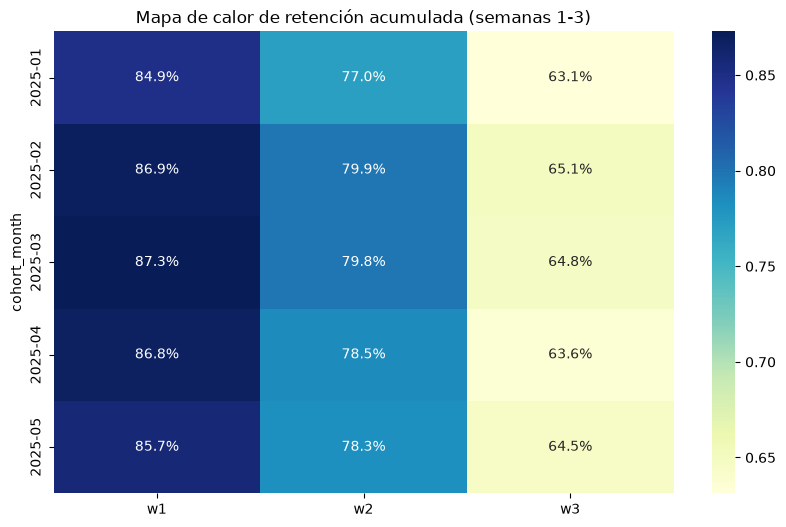

In [19]:
# Porcentaje de retención por cohorte y visualización
retention_df = cohorte_final.copy()
retention_df['w1'] = retention_df['retenido_w1'] / retention_df['total_usuarios']
retention_df['w2'] = retention_df['retenido_w2'] / retention_df['total_usuarios']
retention_df['w3'] = retention_df['retenido_w3'] / retention_df['total_usuarios']

heatmap_data = retention_df[['w1', 'w2', 'w3']]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1%', cmap='YlGnBu')
plt.title('Mapa de calor de retención acumulada (semanas 1-3)')
plt.show()


**Diagnóstico de retención:** *(completar tras ejecutar la query corregida — la lógica acumulada suele arrojar porcentajes de retención más altos que la versión anterior con `BETWEEN`, ya que ahora cuenta a cualquier usuario que regresó desde esa semana en adelante, no solo en el rango exacto. Describe aquí qué cohortes retienen mejor y si hay una tendencia de mejora o deterioro mes a mes.)*

## 5. Test estadístico del experimento de checkout

**Hipótesis:**
- H₀: no hay diferencia significativa en la tasa de conversión entre control y tratamiento (la nueva interfaz no tiene efecto).
- H₁: existe una diferencia significativa entre ambos grupos (la nueva interfaz sí tiene efecto).

**Test:** Z-test de proporciones. **Nivel de significancia:** α = 0.05.

In [20]:
# Carga del dataset del experimento A/B
experimento = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
experimento.head(5)


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [21]:
# Z-test de proporciones sobre la tasa de conversión (control vs. tratamiento)
resumen = experimento.groupby('variante')['convirtio'].agg(['sum', 'count'])

exitos = [resumen.loc['control', 'sum'], resumen.loc['tratamiento', 'sum']]
observaciones = [resumen.loc['control', 'count'], resumen.loc['tratamiento', 'count']]

z_stat, p_value = proportions_ztest(count=exitos, nobs=observaciones)

alpha = 0.05
print(f"Z-stat  : {z_stat:.4f}")
print(f"p-value : {p_value:.4f}")

if p_value < alpha:
    print("Resultado: se rechaza H0. Existe una diferencia estadísticamente significativa.")
else:
    print("Resultado: no se rechaza H0. No hay evidencia suficiente de una diferencia.")


Z-stat  : -0.8133
p-value : 0.4161
Resultado: no se rechaza H0. No hay evidencia suficiente de una diferencia.


**Diagnóstico del experimento:** con p-value = 0.4161 (muy por encima de α = 0.05), no hay evidencia estadística de que la nueva interfaz de checkout modifique la tasa de conversión. La recomendación es no adoptar el cambio basándose únicamente en este resultado, o extender la duración/tamaño de muestra del experimento si se sospecha un efecto pequeño no detectado por falta de poder estadístico.

## 6. Dashboard de comunicación de resultados

El análisis se complementa con un dashboard en Power BI construido sobre los datasets limpios (`orders_clean.csv`, `catalog_clean.csv`, `marketing_clean.csv`) y una tabla de fechas (`dim_fecha`) generada en DAX.

**Vista Overview:** KPIs de Revenue total, Profit neto, Gasto en marketing y Ticket promedio; evolución mensual del profit con línea de tendencia y pronóstico; comparación de Revenue y Margen operativo por categoría de producto.

**Vista Detalle:** tabla de productos con Revenue, Profit neto, cantidad vendida y categoría, con filtros de fecha y categoría, y gráfico de unidades vendidas por producto.

**Medidas DAX principales:** `Revenue total`, `Costo total`, `Margen operativo`, `Profit neto` (descontando marketing), `Ticket promedio` y `Cantidad promedio productos` (ambas a nivel pedido con `AVERAGEX`), y una tabla de calendario (`dim_fecha`) con Año, Mes, Año-Mes y Trimestre.

### Enlace del dashboard

In [22]:
# Enlace al archivo .pbix y a los datasets limpios
link = "https://drive.google.com/drive/folders/1r3v3NGCElsp8EK_20WXUWsSm7lF0JtDh?usp=sharing"
print(link)


https://drive.google.com/drive/folders/1r3v3NGCElsp8EK_20WXUWsSm7lF0JtDh?usp=sharing


## Conclusiones y recomendaciones

- **Rentabilidad:** el negocio es rentable, con un margen neto de ~11.5% tras descontar costos de producto y marketing.
- **Concentración de producto:** `laptop-gaming-16gb` y la categoría Electrónica dominan el revenue, lo que representa tanto la principal fuente de ingresos como un riesgo de dependencia — vale la pena evaluar estrategias de diversificación en Hogar y Moda.
- **Funnel:** la mayor fuga de usuarios ocurre en el paso de pago (`begin_checkout` → `add_payment_info`), la prioridad de optimización más clara del embudo.
- **Retención:** *(agregar hallazgo principal tras completar el diagnóstico de la Sección 4)*.
- **Experimento de checkout:** la nueva interfaz no mostró un efecto estadísticamente significativo sobre la conversión; no se recomienda su adopción basándose solo en esta prueba.